# Step 1 — Load Dataset

In [48]:
import pandas as pd
import numpy as np

df = pd.read_csv("Luxury_Housing_Bangalore.csv")

print(df.head())
print(df.shape)
print(df.info())

  Property_ID       Micro_Market Project_Name Developer_Name  Unit_Size_Sqft  \
0  PROP000001      Sarjapur Road    Project_0            RMZ          4025.0   
1  PROP000002        Indiranagar    Project_1    Puravankara          5760.0   
2  PROP000003  Bannerghatta Road    Project_2   Tata Housing          7707.0   
3  PROP000004       bellary road    Project_3        Embassy          6192.0   
4  PROP000005        Koramangala    Project_4        SNN Raj          7147.0   

  Configuration     Ticket_Price_Cr Transaction_Type Buyer_Type  \
0          4bhk  12.750846039118798          Primary        NRI   
1          3Bhk  16.292151871065954          Primary      Other   
2          4bhk  10.517724412961911          Primary        HNI   
3          3BHK   9.396367494232896          Primary        HNI   
4          4Bhk  15.345392444511946        Secondary        HNI   

  Purchase_Quarter  Connectivity_Score  Amenity_Score   Possession_Status  \
0       2025-03-31            7.990091 

# Step 2 — Data Cleaning

## 2.1 Remove Duplicates

In [49]:
df.drop_duplicates(inplace=True)

## 2.2 Handle Missing Values

In [50]:
df.isnull().sum()

,0
Property_ID,0
Micro_Market,0
Project_Name,0
Developer_Name,0
Unit_Size_Sqft,9957
Configuration,0
Ticket_Price_Cr,9913
Transaction_Type,0
Buyer_Type,0
Purchase_Quarter,0


### Fill Numeric Columns

In [51]:
df['Amenity_Score'].fillna(df['Amenity_Score'].median(), inplace=True)

/tmp/ipykernel_3858/3790030313.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Amenity_Score'].fillna(df['Amenity_Score'].median(), inplace=True)


### Fill Categorical Columns

In [52]:
df['Possession_Status'].fillna("Unknown", inplace=True)

/tmp/ipykernel_3858/1422631905.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Possession_Status'].fillna("Unknown", inplace=True)


#2.3 Clean Ticket Price

## Cleaning Code

In [53]:
df['Ticket_Price_Cr'] = (
    df['Ticket_Price_Cr']
    .astype(str)
    .str.replace('₹', '')
    .str.replace('Cr', '')
    .str.replace('Crore', '')
    .str.strip()
)

df['Ticket_Price_Cr'] = pd.to_numeric(
    df['Ticket_Price_Cr'],
    errors='coerce'
)

#2.4 Normalize Text

In [54]:
df['Developer_Name'] = df['Developer_Name'].str.title().str.strip()

df['Micro_Market'] = (
    df['Micro_Market']
    .str.title()
    .str.strip()
)

# Step 3 — Feature Engineering

## 3.1 Price per Sqft

In [55]:
df['Price_per_Sqft'] = (
    df['Ticket_Price_Cr'] * 10000000
) / df['Unit_Size_Sqft']

## 3.2 Booking Flag

In [56]:
df['Booking_Flag'] = df['Possession_Status'].apply(
    lambda x: 1 if x == "Booked" else 0
)

## 3.3 Quarter Number

In [57]:
df['Purchase_Quarter'] = pd.to_datetime(df['Purchase_Quarter'])
df['Quarter_Number'] = df['Purchase_Quarter'].dt.quarter
df['Year'] = df['Purchase_Quarter'].dt.year
df['Purchase_Quarter_Str'] = df['Year'].astype(str) + '-Q' + df['Quarter_Number'].astype(str)


# Step 4 — Exploratory Data Analysis (EDA)

## 4.1 Booking Status Distribution

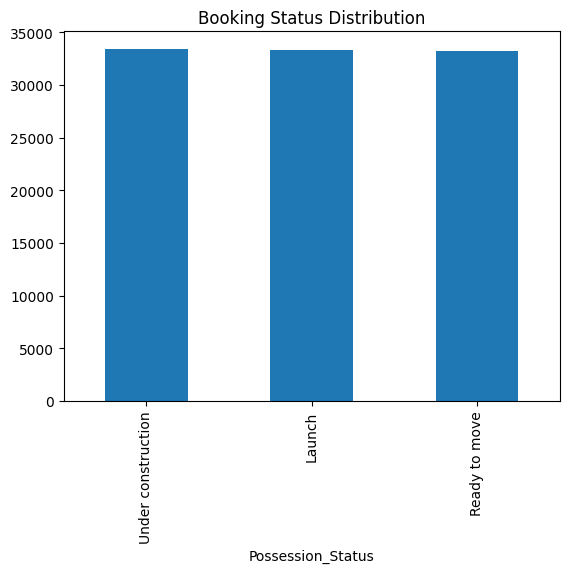

In [58]:
import matplotlib.pyplot as plt

df['Possession_Status'].value_counts().plot(kind='bar')

plt.title("Booking Status Distribution")
plt.show()

## 4.2 Top Builders

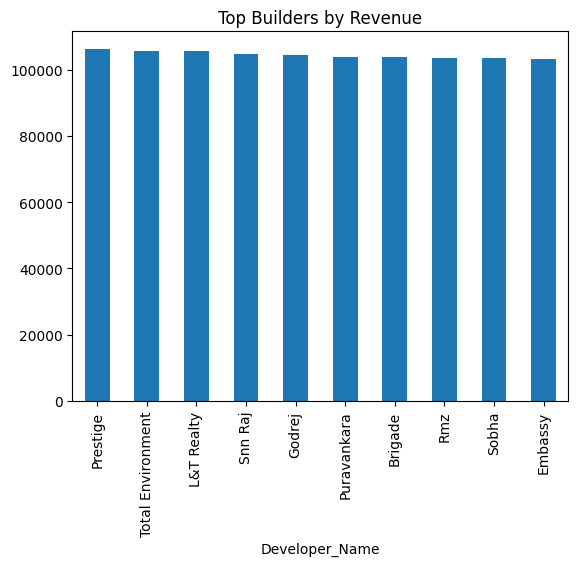

In [59]:
top_builders = (
    df.groupby('Developer_Name')['Ticket_Price_Cr']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_builders.plot(kind='bar')
plt.title("Top Builders by Revenue")
plt.show()

## 4.3 Correlation Heatmap

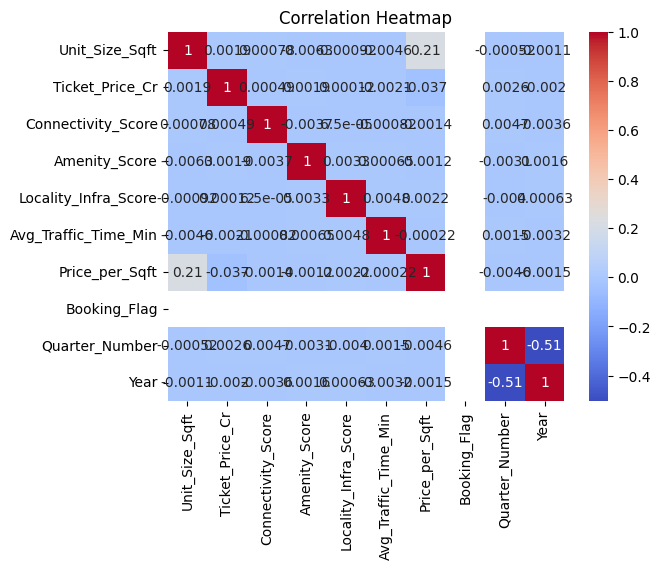

In [60]:
import seaborn as sns

numeric_cols = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# Step 5 — Save Clean Dataset

In [61]:
import os

os.makedirs('data/processed', exist_ok=True)

df.to_csv(
    "data/processed/cleaned_housing.csv",
    index=False
)

# Step 6 — MySQL Database Integration

## 6.1 Install sqlite

In [62]:
import sqlite3

## 6.2 Connect Python to MySQL

In [63]:
conn = sqlite3.connect("luxury_housing.db")

In [64]:
df.to_sql(
    'housing_sales',
    conn,
    if_exists='replace',
    index=False
)

100000

# 6.3 SQL Queries

In [65]:
query = "SELECT * FROM housing_sales LIMIT 5"

result = pd.read_sql(query, conn)

print(result)

  Property_ID       Micro_Market Project_Name Developer_Name  Unit_Size_Sqft  \
0  PROP000001      Sarjapur Road    Project_0            Rmz          4025.0   
1  PROP000002        Indiranagar    Project_1    Puravankara          5760.0   
2  PROP000003  Bannerghatta Road    Project_2   Tata Housing          7707.0   
3  PROP000004       Bellary Road    Project_3        Embassy          6192.0   
4  PROP000005        Koramangala    Project_4        Snn Raj          7147.0   

  Configuration  Ticket_Price_Cr Transaction_Type Buyer_Type  \
0          4bhk        12.750846          Primary        NRI   
1          3Bhk        16.292152          Primary      Other   
2          4bhk        10.517724          Primary        HNI   
3          3BHK         9.396367          Primary        HNI   
4          4Bhk        15.345392        Secondary        HNI   

      Purchase_Quarter  ...  Sales_Channel  NRI_Buyer Locality_Infra_Score  \
0  2025-03-31 00:00:00  ...         Broker        yes   

In [66]:
query = """
SELECT COUNT(*) AS total_records
FROM housing_sales
"""

result = pd.read_sql(query, conn)

print(result)

   total_records
0         100000


In [67]:
query = """
SELECT Possession_Status AS Booking_Status,
COUNT(*) AS total
FROM housing_sales
GROUP BY Possession_Status
"""

result = pd.read_sql(query, conn)

print(result)

       Booking_Status  total
0              Launch  33341
1       Ready to move  33249
2  Under construction  33410


In [68]:
query = """
SELECT Developer_Name AS Builder,
AVG(Ticket_Price_Cr) AS avg_price
FROM housing_sales
GROUP BY Developer_Name
ORDER BY avg_price DESC
"""

result = pd.read_sql(query, conn)

print(result)

              Builder  avg_price
0               Sobha  12.887278
1   Total Environment  12.826206
2          L&T Realty  12.789966
3              Godrej  12.766537
4         Puravankara  12.735030
5                 Rmz  12.729200
6            Prestige  12.721970
7        Tata Housing  12.660182
8             Snn Raj  12.613327
9             Embassy  12.592975
10            Brigade  12.590695


In [69]:
query = """
SELECT Micro_Market,
SUM(Ticket_Price_Cr) AS revenue
FROM housing_sales
GROUP BY Micro_Market
ORDER BY revenue DESC
"""

result = pd.read_sql(query, conn)

print(result)

         Micro_Market       revenue
0       Sarjapur Road  74430.023695
1           Jayanagar  73226.416039
2   Bannerghatta Road  73154.790866
3            Jp Nagar  73144.944996
4             Mg Road  71912.543479
5              Hebbal  71557.112931
6         Indiranagar  71359.281850
7        Bellary Road  71330.018173
8          Whitefield  71194.167727
9     Kanakapura Road  70992.365903
10    Electronic City  70836.507654
11        Rajajinagar  70822.604600
12             Domlur  70750.397980
13          Yelahanka  70742.209690
14        Hennur Road  70206.572662
15        Koramangala  70162.816845


In [70]:
conn.close()

## 6.4 Load Data into SQL

In [71]:
import sqlite3
import pandas as pd

# Create connection
conn = sqlite3.connect("luxury_housing.db")

# Reload 'df' from the saved CSV to ensure it is defined and up-to-date
df = pd.read_csv("/content/data/processed/cleaned_housing.csv")

# Load dataframe into SQLite
df.to_sql(
    'housing_sales',
    conn,
    if_exists='replace',
    index=False
)

# Verify data
query = "SELECT * FROM housing_sales LIMIT 5"

result = pd.read_sql(query, conn)

print(result)

# Close connection
conn.close()

  Property_ID       Micro_Market Project_Name Developer_Name  Unit_Size_Sqft  \
0  PROP000001      Sarjapur Road    Project_0            Rmz          4025.0   
1  PROP000002        Indiranagar    Project_1    Puravankara          5760.0   
2  PROP000003  Bannerghatta Road    Project_2   Tata Housing          7707.0   
3  PROP000004       Bellary Road    Project_3        Embassy          6192.0   
4  PROP000005        Koramangala    Project_4        Snn Raj          7147.0   

  Configuration  Ticket_Price_Cr Transaction_Type Buyer_Type Purchase_Quarter  \
0          4bhk        12.750846          Primary        NRI       2025-03-31   
1          3Bhk        16.292152          Primary      Other       2024-06-30   
2          4bhk        10.517724          Primary        HNI       2023-12-31   
3          3BHK         9.396367          Primary        HNI       2024-03-31   
4          4Bhk        15.345392        Secondary        HNI       2024-12-31   

   ...  Sales_Channel  NRI_Buyer

In [72]:
import pandas as pd
import sqlite3

connection = sqlite3.connect(
    "luxury_housing.db"
)

dataframe = pd.read_sql(
    "SELECT * FROM housing_sales",
    connection
)

dataframe.to_csv(
    "cleaned_housing.csv",
    index=False
)

connection.close()

# 7. Streamlit Dashboard

In [73]:
!pip install streamlit plotly


In [74]:
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb

!dpkg -i cloudflared-linux-amd64.deb

--2026-05-13 09:29:56--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64.deb [following]
--2026-05-13 09:29:57--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64.deb
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/ec689fe1-d727-4ebd-bbc3-5967730ab54e?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-05-13T10%3A15%3A27Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64.deb&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4d

In [75]:
%%writefile app.py

import streamlit as st
import pandas as pd
import sqlite3
import plotly.express as px

# -----------------------------
# PAGE CONFIG
# -----------------------------
st.set_page_config(
    page_title="Luxury Housing Dashboard",
    layout="wide"
)

# -----------------------------
# LOAD DATA
# -----------------------------
@st.cache_data
def load_data():

    connection = sqlite3.connect(
        "luxury_housing.db"
    )

    query = """
    SELECT *
    FROM housing_sales
    """

    dataframe = pd.read_sql(
        query,
        connection
    )

    connection.close()

    # Ensure Developer_Name and Purchase_Quarter_Str are available for filters
    dataframe['Developer_Name'] = dataframe['Developer_Name'].str.title().str.strip()
    dataframe['Purchase_Quarter'] = pd.to_datetime(dataframe['Purchase_Quarter'])
    dataframe['Quarter_Number'] = dataframe['Purchase_Quarter'].dt.quarter
    dataframe['Year'] = dataframe['Purchase_Quarter'].dt.year
    dataframe['Purchase_Quarter_Str'] = dataframe['Year'].astype(str) + '-Q' + dataframe['Quarter_Number'].astype(str)

    return dataframe


df = load_data()

# -----------------------------
# SIDEBAR FILTERS
# -----------------------------
st.sidebar.header("🔍 Filter Dashboard")

selected_builder = st.sidebar.multiselect(
    "Select Developer",
    options=sorted(df['Developer_Name'].dropna().unique()),
    default=sorted(df['Developer_Name'].dropna().unique())
)

selected_quarter = st.sidebar.multiselect(
    "Select Quarter (YYYY-Q)",
    options=sorted(df['Purchase_Quarter_Str'].dropna().unique()),
    default=sorted(df['Purchase_Quarter_Str'].dropna().unique())
)

selected_market = st.sidebar.multiselect(
    "Select Micro Market",
    options=sorted(df['Micro_Market'].dropna().unique()),
    default=sorted(df['Micro_Market'].dropna().unique())
)

# Apply filters
filtered_df = df[
    (df['Developer_Name'].isin(selected_builder)) &
    (df['Purchase_Quarter_Str'].isin(selected_quarter)) &
    (df['Micro_Market'].isin(selected_market))
]

# -----------------------------
# TITLE
# -----------------------------
st.title("🏠 Luxury Housing Sales Analysis Dashboard")

# -----------------------------
# KPI SECTION
# -----------------------------
st.subheader("📊 Key Performance Indicators")

total_revenue = (
    filtered_df['Ticket_Price_Cr'].sum()
)

total_bookings = (
    filtered_df['Booking_Flag'].sum()
)

booking_conversion_rate = (
    filtered_df['Booking_Flag'].mean() * 100
)

average_amenity_score = (
    filtered_df['Amenity_Score'].mean()
)

col1, col2, col3, col4 = st.columns(4)

col1.metric(
    "💰 Total Revenue (Cr)",
    f"{total_revenue:.2f}"
)

col2.metric(
    "🏠 Total Bookings",
    int(total_bookings)
)

col3.metric(
    "📈 Booking Conversion %",
    f"{booking_conversion_rate:.2f}%"
)

col4.metric(
    "⭐ Avg Amenity Score",
    f"{average_amenity_score:.2f}"
)
# -----------------------------
# MARKET TRENDS
# -----------------------------
st.subheader("📈 Market Trends")

market_trend = (
    filtered_df.groupby(
        ['Purchase_Quarter_Str', 'Micro_Market']
    )['Booking_Flag']
    .sum()
    .reset_index()
)

fig_market = px.line(
    market_trend,
    x='Purchase_Quarter_Str',
    y='Booking_Flag',
    color='Micro_Market',
    markers=True
)

st.plotly_chart(
    fig_market,
    use_container_width=True
)

# -----------------------------
# BUILDER PERFORMANCE
# -----------------------------
st.subheader("🏗 Developer Performance")

builder_performance = (
    filtered_df.groupby('Developer_Name')
    ['Ticket_Price_Cr']
    .sum()
    .reset_index()
    .sort_values(
        by='Ticket_Price_Cr',
        ascending=False
    )
)

fig_builder = px.bar(
    builder_performance,
    x='Developer_Name',
    y='Ticket_Price_Cr'
)

st.plotly_chart(
    fig_builder,
    use_container_width=True
)

# -----------------------------
# CONFIGURATION DEMAND
# -----------------------------
st.subheader("🏢 Configuration Demand")

configuration_data = (
    filtered_df['Configuration']
    .value_counts()
    .reset_index()
)

configuration_data.columns = [
    'Configuration',
    'Count'
]

fig_configuration = px.pie(
    configuration_data,
    names='Configuration',
    values='Count'
)

st.plotly_chart(
    fig_configuration,
    use_container_width=True
)

# -----------------------------
# TOP BUILDERS TABLE
# -----------------------------
st.subheader("🏆 Top 5 Developers")

st.dataframe(
    builder_performance.head(5),
    use_container_width=True
)

# -----------------------------
# RAW DATA
# -----------------------------
with st.expander("View Raw Data"):
    st.dataframe(
        filtered_df,
        use_container_width=True
    )

# -----------------------------
# MAP VISUALIZATION
# -----------------------------
st.subheader("🗺 Luxury Housing Locations")

if 'Latitude' in filtered_df.columns and 'Longitude' in filtered_df.columns:

    map_data = filtered_df[
        ['Latitude', 'Longitude']
    ].dropna()

    st.map(map_data)

else:
    st.warning(
        "Latitude and Longitude columns not found."
    )


Overwriting app.py


In [76]:
!streamlit run app.py &>/content/logs.txt &

In [77]:
!cloudflared tunnel --url http://localhost:8501

2026-05-13T09:29:59Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-13T09:29:59Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-13T09:30:06Z INF +--------------------------------------------------------------------------------------------+
2026-05-13T09:30:06Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-13T09:30:06Z INF |  https://norm-prohibited-nominations-events.trycloudfl